# Анализ датасета titanic 

**Целью** данного исследования является анализ классического датасета titanic с выявлением факторов наиболее влияющих на выживаемость при крушении.

Одной из наиболее важных **задач** является подбор наилучшей модели бинарной классификации для предсказания выживаемости пассажиров.

**Структура исследования**:
1. Загрузка и первичный анализ данных
2. Анализ распределений признаков и очистка данных
3. Выбор и обучение моделей 
4. Оценка результатов и выбор лучшей модели



In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Загрузка и первичный анализ данных

In [3]:
# Список названий признаков датасета Titanic
features = [
    'passenger_id',
    'survived',
    'pclass',
    'name',
    'sex',
    'age',
    'sibsp',
    'parch',
    'ticket',
    'fare',
    'cabin',
    'embarked'
]

# Список описаний для каждого признака (в том же порядке)
descriptions = [
    'Уникальный идентификатор пассажира',
    'Целевая переменная: 1 – выжил, 0 – погиб',
    'Класс билета: 1 (первый), 2 (второй), 3 (третий)',
    'Имя пассажира (включая титул и фамилию)',
    'Пол: male / female',
    'Возраст в годах',
    'Количество братьев/сестер на борту',
    'Количество родителей или детей на борту',
    'Номер билета (может содержать буквы)',
    'Стоимость билета в фунтах стерлингов',
    'Номер каюты',
    'Порт посадки: C = Cherbourg, Q = Queenstown, S = Southampton'
]

descriptions_table = pd.DataFrame({
    "Признак": features,
    "Описание": descriptions
    })

print(descriptions_table)

         Признак                                           Описание
0   passenger_id                 Уникальный идентификатор пассажира
1       survived           Целевая переменная: 1 – выжил, 0 – погиб
2         pclass   Класс билета: 1 (первый), 2 (второй), 3 (третий)
3           name            Имя пассажира (включая титул и фамилию)
4            sex                                 Пол: male / female
5            age                                    Возраст в годах
6          sibsp                 Количество братьев/сестер на борту
7          parch            Количество родителей или детей на борту
8         ticket               Номер билета (может содержать буквы)
9           fare               Стоимость билета в фунтах стерлингов
10         cabin                                        Номер каюты
11      embarked  Порт посадки: C = Cherbourg, Q = Queenstown, S...


In [4]:
# Прочитаем файл датасета
df = pd.read_csv("titanic2.csv")

# Выведем первые 5 строк датасета
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Выведем размеры датасета
df.shape

(891, 12)

In [6]:
# Статистика по числовым признакам
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# Статистика по категориальным признакам
df.describe(include=["object", "bool"])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [8]:
# Выведим количество пропусков по столбцам
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Данные столбца номер каюты содержат много пропусков, поэтому мы удалим столбец, данные возраста заполним медианным значением для устойчивости к выбросам

In [9]:
df = df.drop(columns=["Cabin", "Ticket", "PassengerId", ])

median_age = df.groupby("Sex")["Age"].transform("median")

df["Age"] = df["Age"].fillna(median_age) 



In [10]:
df.dtypes

Survived      int64
Pclass        int64
Name         object
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object

In [11]:
# Отберем признаки по типам объектов
numerical = df.select_dtypes(include="number").columns.to_list()
if "PassengerId" in numerical:
    numerical.remove("PassengerId")
target = "Survived"
if target in numerical:
    numerical.remove(target)
categorical = df.select_dtypes(include="object").columns.to_list()
print(f"Числовые: {numerical}")
print(f"Категориальные: {categorical}")

Числовые: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Категориальные: ['Name', 'Sex', 'Embarked']


## 2. Анализ распределений признаков

Text(0.5, 1.0, 'Распределение пассажиров по выживаемости')

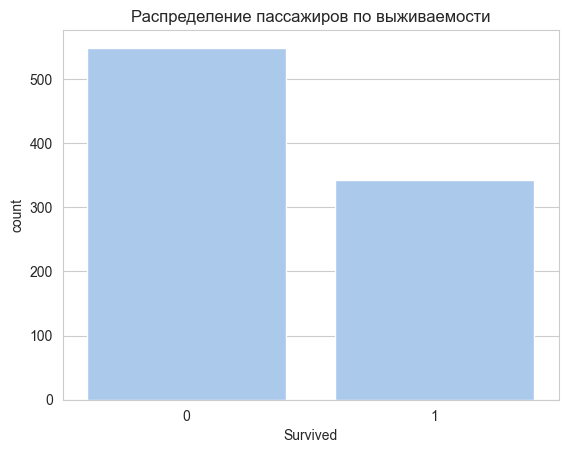

In [12]:
sns.set_style('whitegrid')
sns.set_palette('pastel')
sns.countplot(df, x="Survived")
plt.title('Распределение пассажиров по выживаемости')

In [13]:
survived_percent = len(df[df["Survived"] == 1]) / len(df) * 100
print(f"Процент выживших:{survived_percent: .2f}")

Процент выживших: 38.38


Text(0.5, 1.0, 'Распределение пассажиров по полу')

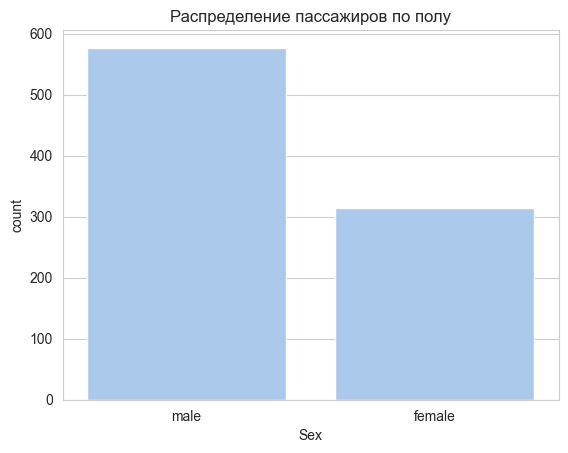

In [14]:
sns.countplot(df, x="Sex")
plt.title('Распределение пассажиров по полу')


In [15]:
female_percent = len(df[df["Sex"] == "female"]) / len(df) * 100
print(f"Процент женщин на корабле:{female_percent: .2f}")

Процент женщин на корабле: 35.24


<Axes: xlabel='Embarked', ylabel='count'>

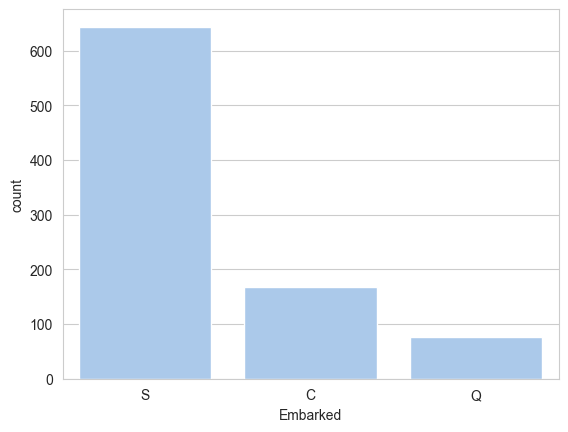

In [16]:
# Распределение по порту посадки
sns.countplot(df, x="Embarked")

<Axes: title={'center': 'Гистограмма распределения возраста'}, xlabel='Age', ylabel='Count'>

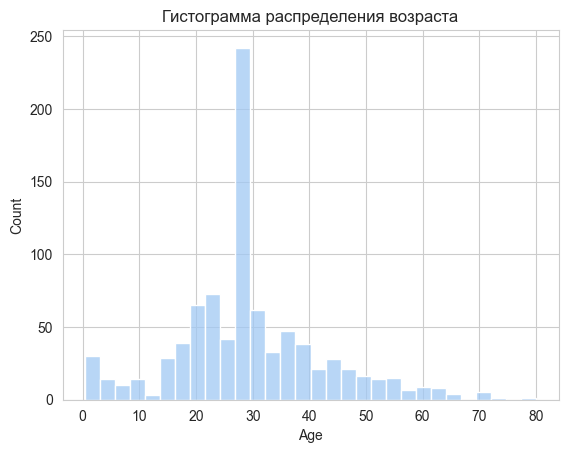

In [17]:
plt.title('Гистограмма распределения возраста')
sns.histplot(df, x="Age")

In [18]:
print(df["Age"].mode())

0    29.0
Name: Age, dtype: float64


<Axes: title={'center': 'Распределение количества родитилей или детей на борту'}, xlabel='Parch', ylabel='Count'>

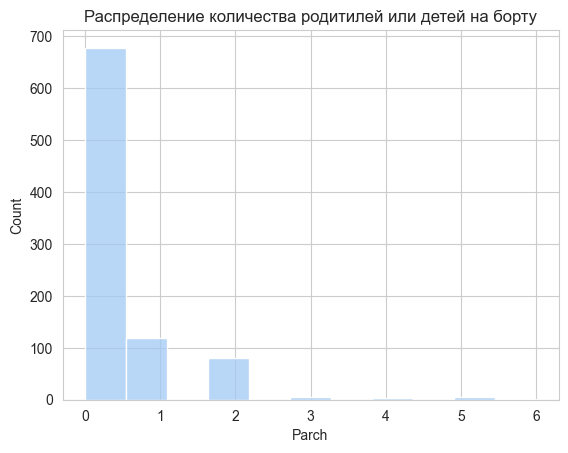

In [19]:
plt.title("Распределение количества родитилей или детей на борту")
sns.histplot(df, x="Parch")

<Axes: title={'center': 'Распределение братьев или сестер на борту'}, xlabel='SibSp', ylabel='Count'>

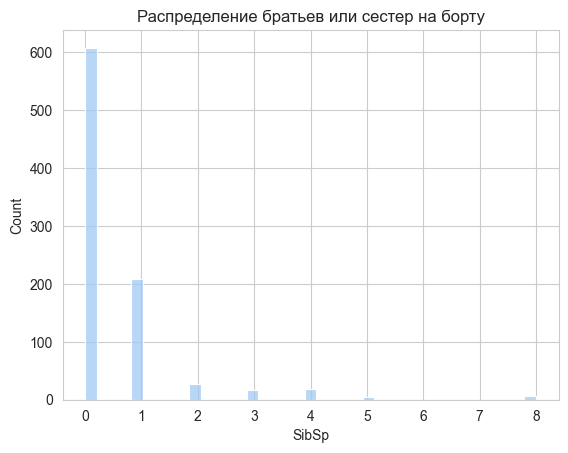

In [20]:
plt.title("Распределение братьев или сестер на борту")
sns.histplot(df, x="SibSp")

In [21]:
# Цены билетов по классам
df.groupby("Pclass")["Fare"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
Pclass,,,,
1,84.154687,60.2875,0.0,512.3292
2,20.662183,14.2500,0.0,73.5000
3,13.675550,8.0500,0.0,69.5500


In [22]:
womans_alive = df[(df["Sex"] == "female") & (df["Survived"] == 1)]["Sex"].count()
mans_alive = df[(df["Sex"] == "male") & (df["Survived"] == 1)]["Sex"].count()
alive = df[df["Survived"] == 1]["Survived"].count()

print(f"среди {alive} людей: мужчин выжило {mans_alive}, женщин - {womans_alive}")

среди 342 людей: мужчин выжило 109, женщин - 233


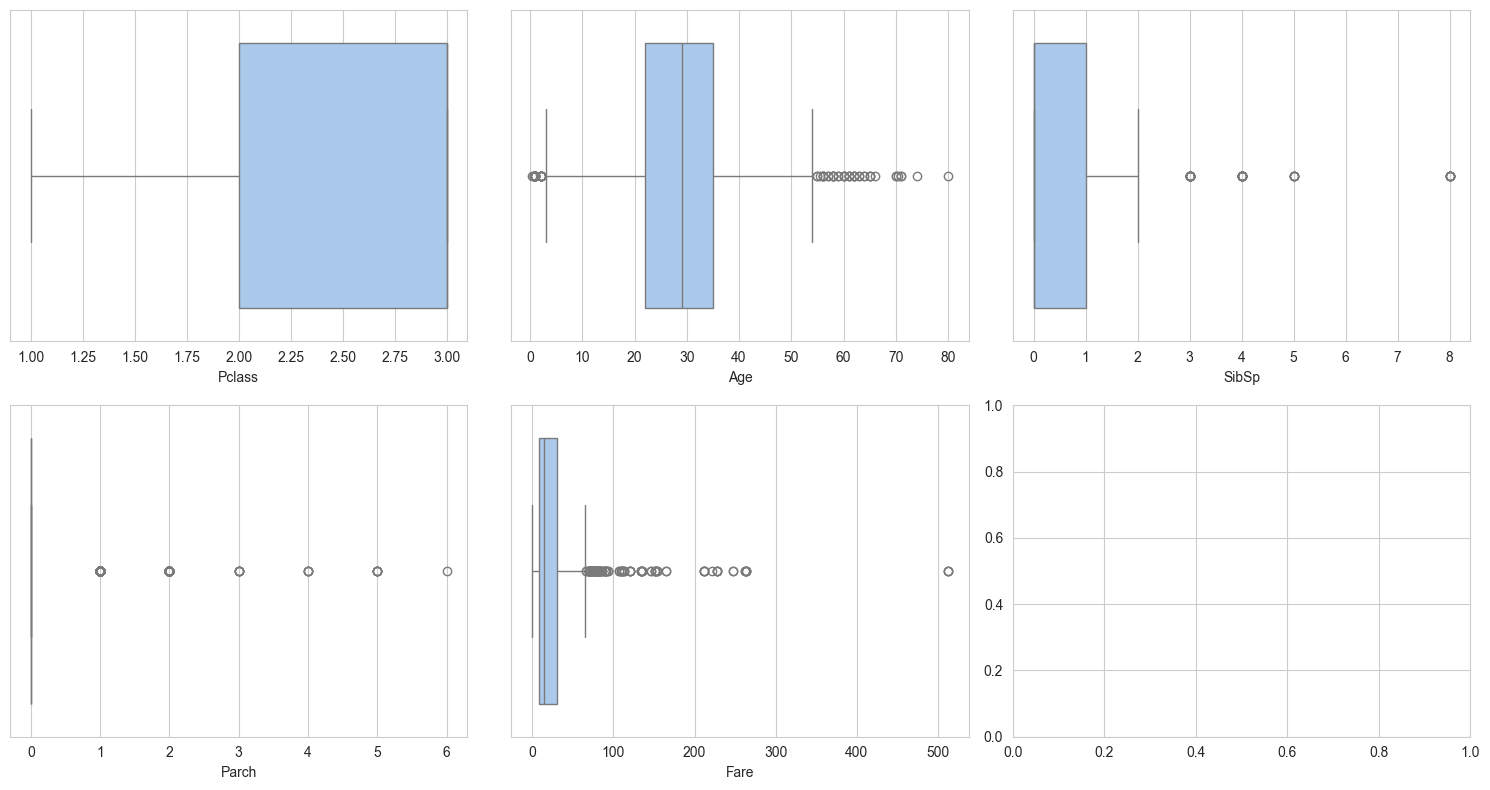

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
# axes - это массив (2,3), можно развернуть в одномерный
for i, feature in enumerate(numerical):  # предполагаем, что ровно 6 элементов
    sns.boxplot(data=df, x=feature, ax=axes.flat[i])
plt.tight_layout()
plt.show()

Проверим являются ли выбросами значения за пределами 1-3х квартилей для показателя Fare

<Axes: xlabel='Pclass', ylabel='Fare'>

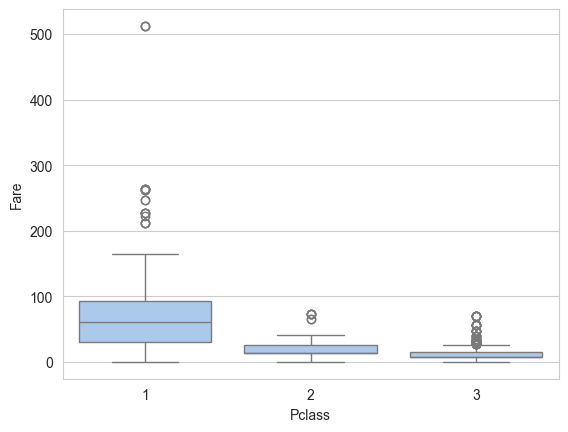

In [24]:
sns.boxplot(data=df, x="Pclass", y="Fare")

In [25]:
expensive_ticket_count = df[df["Fare"] > 100]["Fare"].count()
num_of_first_class = df[df["Pclass"] == 1]["Pclass"].count()
mean_first_class = df[df["Pclass"] == 1]["Fare"].mean()
median_first_class = df[df["Pclass"] == 1]["Fare"].median()
mode_first_class = df[df["Pclass"] == 1]["Fare"].mode()[0]
maximum_cost_for_class = df.groupby("Pclass")["Fare"].max()

print(f"Всего дорогих билетов: {expensive_ticket_count}\n")
print(f"Всего билетов первого класса: {num_of_first_class}\n")
print(f"Средняя стоимость билетов первого класса: {mean_first_class : .2f}\n")
print(f"Медианная стоимость билетов первого класса: {median_first_class: .2f}\n")
print(f"Наиболее частая стоимость билетов первого класса: {mode_first_class : .2f}\n")
print(maximum_cost_for_class)

Всего дорогих билетов: 53

Всего билетов первого класса: 216

Средняя стоимость билетов первого класса:  84.15

Медианная стоимость билетов первого класса:  60.29

Наиболее частая стоимость билетов первого класса:  26.55

Pclass
1    512.3292
2     73.5000
3     69.5500
Name: Fare, dtype: float64


В результате анализа приходим к выводу о том, что действительно выбросы присутствуют, но они связаны вероятно с наличием "люксовых" мест или мест купленных в последний момент, из-за чего они стоят гораздо дороже остальных. 

Для использования линейных моделей подготовим очищенный датасет для более чистых результатов и сравним в последствии с датасетом без изменений.

Если же удалить все выбросы по Fare то потеряем много семплов в датасете, поэтому найдем и исключим выбросы по первому классу, в котором ожидаемо обнаружены наибольшие значения цены. 

Также заметим, что все выбросы сосредоточены выше верхней границы класса, соответственно требованиями на нижнюю границу можно пренебречь.

In [26]:
# Считаем квартили и размах
first_class = df[df["Pclass" ] == 1]
Q1 = first_class["Fare"].quantile(0.25)
Q3 = first_class["Fare"].quantile(0.75)
IQR = Q3 - Q1

# Считаем границу определяющую выбросы
upper_bound = Q3 + 1.5 * IQR


df_cleaned = df[df["Fare"] < upper_bound]

print(f"Выбросов удалено: {len(df) - len(df_cleaned)}")

Выбросов удалено: 20


In [27]:
df.groupby("Pclass")["Survived"].sum()

Pclass
1    136
2     87
3    119
Name: Survived, dtype: int64

In [28]:
df.groupby("Embarked")["Survived"].sum()

Embarked
C     93
Q     30
S    217
Name: Survived, dtype: int64

In [29]:
bins = [0, 18, 35, 60, 100]
labels = ['child', 'young', 'middle-aged', 'senior']
df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

In [30]:
df.groupby("age_group")["Survived"].sum()

C:\Users\Кика\AppData\Local\Temp\ipykernel_26344\2792005824.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["Survived"].sum()


age_group
child           61
young          187
middle-aged     87
senior           7
Name: Survived, dtype: int64

По проведенному анализу выживаемости мы получили, что:
- Большинство выживших это девушки
- Больше всех выживших среди пассажиров первого класа
- Большая часть выживших села в порту S
- Большая часть выживших принадлежит возрастному интервалу от 18 до 35

<Axes: title={'center': 'Матрица корреляций'}>

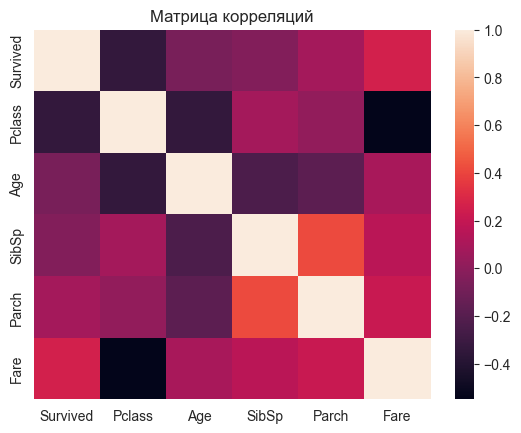

In [31]:
corr_matrix = df.select_dtypes(include="number").corr()
plt.title("Матрица корреляций")
sns.heatmap(corr_matrix)

В целом все данные имеют умеренную корреляцию, поэтому никаких дополнительных доработок данных делать не будем. Перейдем к выбору моделей бинарной классификации.

## 3. Выбор и обучение моделей

Для задач бинарной классификации выберем следующие модели:
- SVM с линейным ядром
- Логистическая регрессия
- Линейная регрессия с L1
- Линейная регрессия с L2
- Байессовский гауссовский классификатор

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge, LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


X = df[numerical]
y = df[target]

X_c = df_cleaned[numerical]
y_c = df_cleaned[target]

# Разделение на тестовую и обучающую выборку
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42, shuffle=True)

# Стандартизируем признаковое пространство
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

scaler_c = StandardScaler()
X_train_c = scaler_c.fit_transform(X_train_c)
X_test_c = scaler_c.transform(X_test_c)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM" : SVC(kernel="linear", random_state=42),
    "Bayes": GaussianNB(),
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01)
}

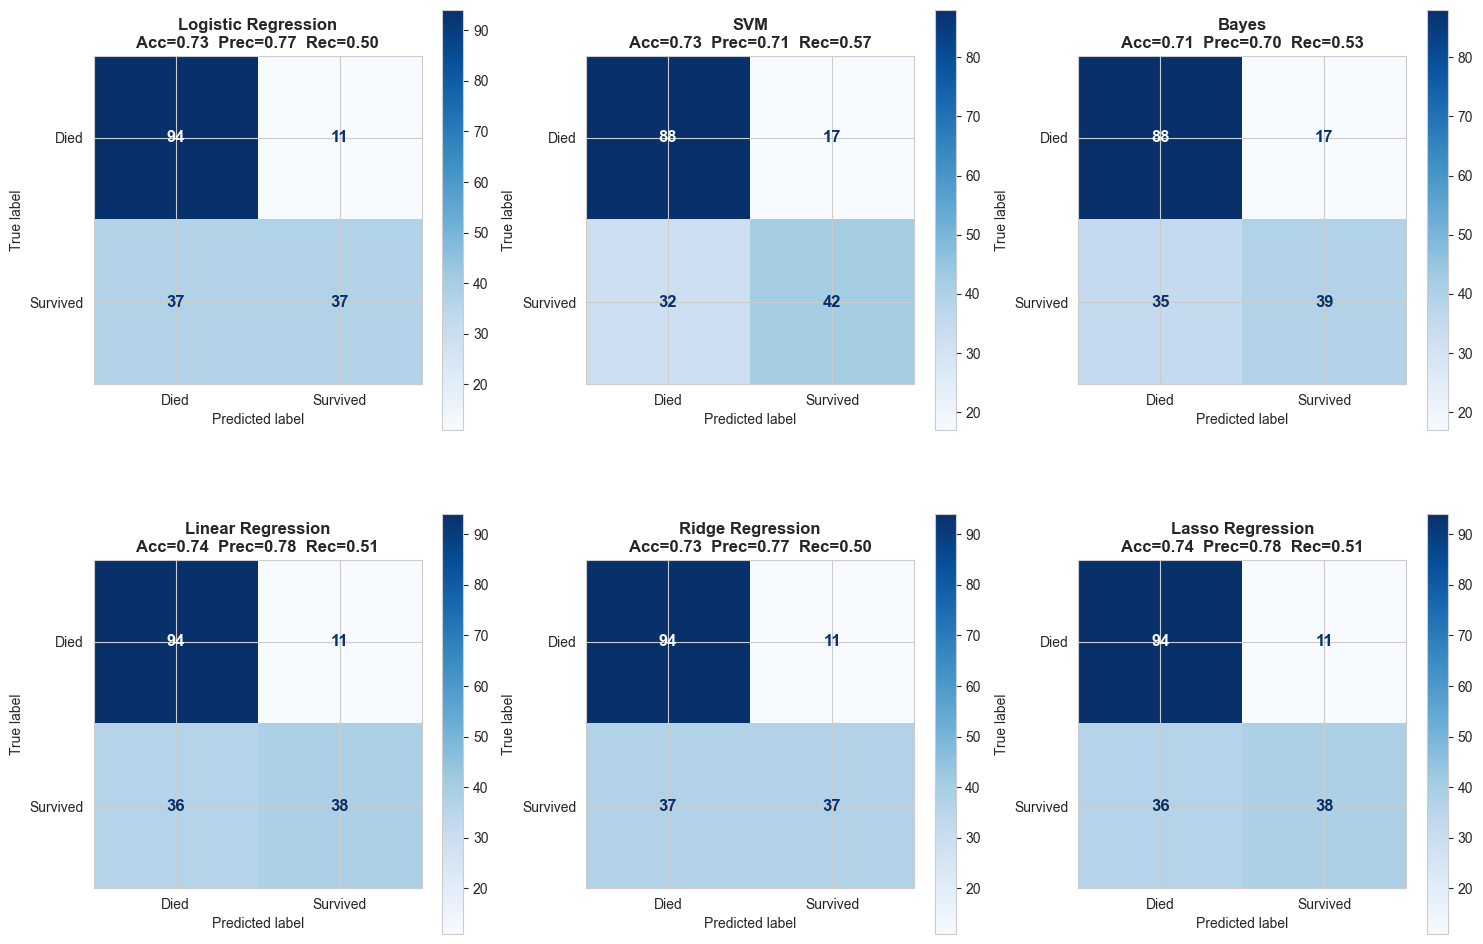

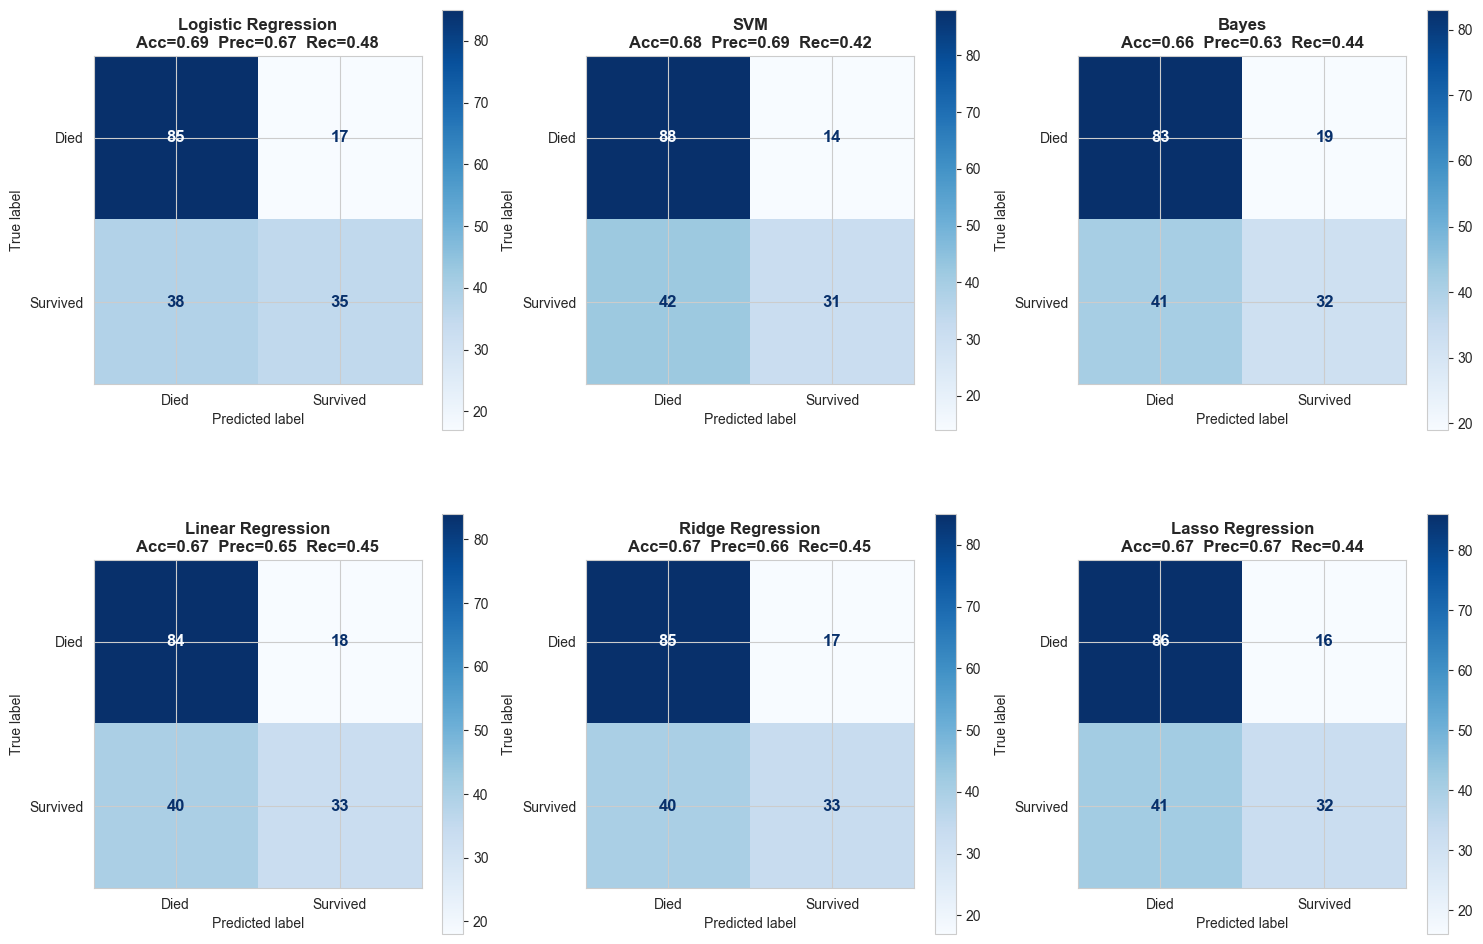

In [35]:
def fit_models(X_train, X_test, y_train, y_test, models):
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))   # увеличил размер
    axes_flat = axes.flatten()
    i = 0
    result = []
    for model_name, model in models.items():
        
        models[model_name].fit(X_train, y_train)
        
        # Для регрессионных моделей
        if model_name in ["Linear Regression","Ridge Regression", "Lasso Regression"]:
            y_pred_cont = model.predict(X_test).flatten()
            y_pred = (y_pred_cont > 0.5).astype(int)
        # Для вероятностных
        else:
            y_pred = models[model_name].predict(X_test)
        
        acc = accuracy_score(y_pred=y_pred, y_true=y_test)
        pre = precision_score(y_pred=y_pred, y_true=y_test)
        rec = recall_score(y_pred=y_pred, y_true=y_test)
        cm = confusion_matrix(y_pred=y_pred, y_true=y_test)
        
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died', 'Survived'])
        disp.plot(ax=axes_flat[i], cmap='Blues', values_format='d',
                text_kw={'fontsize': 12, 'weight': 'bold'})
        
        # Заголовок с метриками
        axes_flat[i].set_title(f'{model_name}\nAcc={acc:.2f}  Prec={pre:.2f}  Rec={rec:.2f}',
                            fontsize=12, fontweight='bold')

    
    
        i += 1
    
        result.append({
            "Model": model_name,
            "Accuracy": f"{acc:.2f}",
            "Precision": f"{pre:.2f}",
            "Recall": f"{rec:.2f}"
        })
        
        
    return result



result1 = pd.DataFrame(fit_models(X_train, X_test, y_train, y_test, models))
result2 = pd.DataFrame(fit_models(X_train_c, X_test_c, y_train_c, y_test_c, models))

In [ ]:
result1.sort_values(["Accuracy", "Precision"], ascending=False)

,Model,Accuracy,Precision,Recall
3,Linear Regression,0.74,0.78,0.51
5,Lasso Regression,0.74,0.78,0.51
0,Logistic Regression,0.73,0.77,0.50
4,Ridge Regression,0.73,0.77,0.50
1,SVM,0.73,0.71,0.57
2,Bayes,0.71,0.70,0.53


In [36]:
result2.sort_values(["Accuracy", "Precision"])

,Model,Accuracy,Precision,Recall
2,Bayes,0.66,0.63,0.44
3,Linear Regression,0.67,0.65,0.45
4,Ridge Regression,0.67,0.66,0.45
5,Lasso Regression,0.67,0.67,0.44
1,SVM,0.68,0.69,0.42
0,Logistic Regression,0.69,0.67,0.48


Как мы видим, модель обученная на очищенных данных обучилась хуже. Значит удалённые наблюдения, вероятно, содержали полезную информацию для предсказания выживания пассажиров Титаника. После удаления выбросов ухудшились почти все метрики: accuracy, precision и recall.

Модели, обученные на исходных данных, можно считать приемлемыми для базовой классификации. Однако значение recall остаётся средним, поэтому качество моделей можно улучшать с помощью подбора признаков, настройки гиперпараметров и использования категориальных переменных.

Лучшим результатом является предсказание линейной регрессии, с порогом достоверности в 0,5.